<a href="https://colab.research.google.com/github/mf2056/F20AA_CW2/blob/main/Step2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Text Processing and Normalization**

In [ ]:
# Installing required libraries

!pip install pandas numpy matplotlib seaborn nltk scikit-learn

In [ ]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

nltk.download('punkt')      # for tokenization
nltk.download('punkt_tab')
nltk.download('stopwords')  # for removing common words
nltk.download('wordnet')    # for lemmatization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Loading Dataset
train = pd.read_csv("train.csv")
train.head()

,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4


In [ ]:
train.shape

(288000, 2)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    288000 non-null  object
 1   rating  288000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


In [ ]:
def basic_clean(text):
    text = str(text)                             # Makes sure text is string
    text = text.lower()                          # Converts text to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)      # Removes punctuation (Not done for Deep learning models)
    text = re.sub(r'\s+', ' ', text).strip()     # Removes extra spaces
    return text

train['text'] = train['text'].apply(basic_clean)
train.head()

,text,rating
0,this place is terrible the people in charge ar...,2
1,terrible service and they are saying that i ne...,1
2,absolutely terrible company they sent me to co...,1
3,to find it either park in front of the tuesday...,4
4,mall location used their services for sedan ni...,4


In [ ]:
# Tokenization
train["tokens"] = train["text"].apply(word_tokenize)
train.head()

,text,rating,tokens
0,this place is terrible the people in charge ar...,2,"[this, place, is, terrible, the, people, in, c..."
1,terrible service and they are saying that i ne...,1,"[terrible, service, and, they, are, saying, th..."
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, they, sent, me..."
3,to find it either park in front of the tuesday...,4,"[to, find, it, either, park, in, front, of, th..."
4,mall location used their services for sedan ni...,4,"[mall, location, used, their, services, for, s..."


In [ ]:
# Stop word removal
stop_words = set(stopwords.words("english"))
stop_words.remove("not")                       # To keep the word 'not'

def remove_stopwords(tokens):
    final_tokens = []
    for w in tokens:
        if w not in stop_words:
            final_tokens.append(w)
    return final_tokens

train["tokens"] = train["tokens"].apply(remove_stopwords)
train.head()

,text,rating,tokens
0,this place is terrible the people in charge ar...,2,"[place, terrible, people, charge, worst, part,..."
1,terrible service and they are saying that i ne...,1,"[terrible, service, saying, never, used, servi..."
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, sent, collecti..."
3,to find it either park in front of the tuesday...,4,"[find, either, park, front, tuesday, morning, ..."
4,mall location used their services for sedan ni...,4,"[mall, location, used, services, sedan, nice, ..."


In [ ]:
# Stemming
stemmer = PorterStemmer()

def stem_words(tokens):
    stems = []
    for w in tokens:
        stemmed_word = stemmer.stem(w)
        stems.append(stemmed_word)
    return stems

train["stemmed"] = train["tokens"].apply(stem_words)

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    lemmas = []
    for w in tokens:
        lemmatized_word = lemmatizer.lemmatize(w)
        lemmas.append(lemmatized_word)
    return lemmas

train["lemmatized"] = train["tokens"].apply(lemmatize_words)

In [ ]:
# Tokens converted to text and compared
train["text_stem"] = train["stemmed"].apply(lambda x: " ".join(x))
train["text_lemma"] = train["lemmatized"].apply(lambda x: " ".join(x))

train[["text","text_stem","text_lemma"]].head(10)

,text,text_stem,text_lemma
0,this place is terrible the people in charge ar...,place terribl peopl charg worst part far yeah ...,place terrible people charge worst part far ye...
1,terrible service and they are saying that i ne...,terribl servic say never use servic lie call n...,terrible service saying never used service lie...
2,absolutely terrible company they sent me to co...,absolut terribl compani sent collect without a...,absolutely terrible company sent collection wi...
3,to find it either park in front of the tuesday...,find either park front tuesday morn mall entra...,find either park front tuesday morning mall en...
4,mall location used their services for sedan ni...,mall locat use servic sedan nice perhap inform...,mall location used service sedan nice perhaps ...
5,ebenezer reformed church is very haughty and t...,ebenez reform church haughti kick attend enoug...,ebenezer reformed church haughty kick attend e...
6,they have relocated wnorth ave oakpark il,reloc wnorth ave oakpark il,relocated wnorth ave oakpark il
7,it was great they really take their time very ...,great realli take time friendli,great really take time friendly
8,ordered the ramen on a cold jan nightwould giv...,order ramen cold jan nightwould give star abl ...,ordered ramen cold jan nightwould give star ab...
9,friendly service and always great food this on...,friendli servic alway great food one goto quic...,friendly service always great food one goto qu...


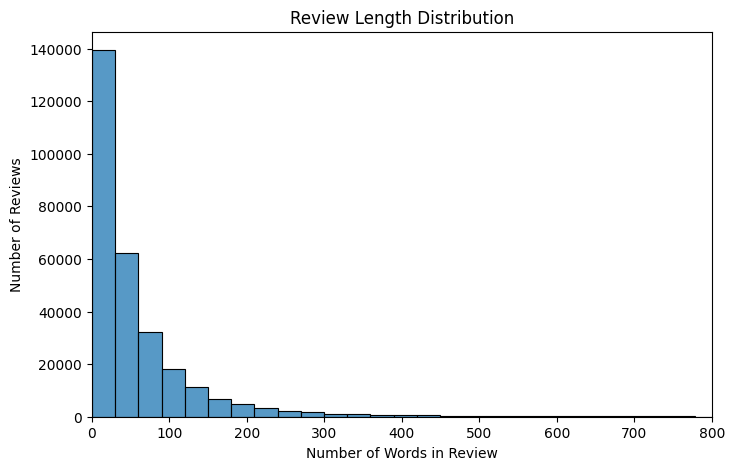

In [ ]:
# Distribution of Review Length
train["review_length"] = train["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(train["review_length"], bins=50)
plt.xlim(0, 800)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words in Review")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
from collections import Counter

all_words = " ".join(train["text_lemma"]).split()
word_freq = Counter(all_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=["Word","Frequency"])

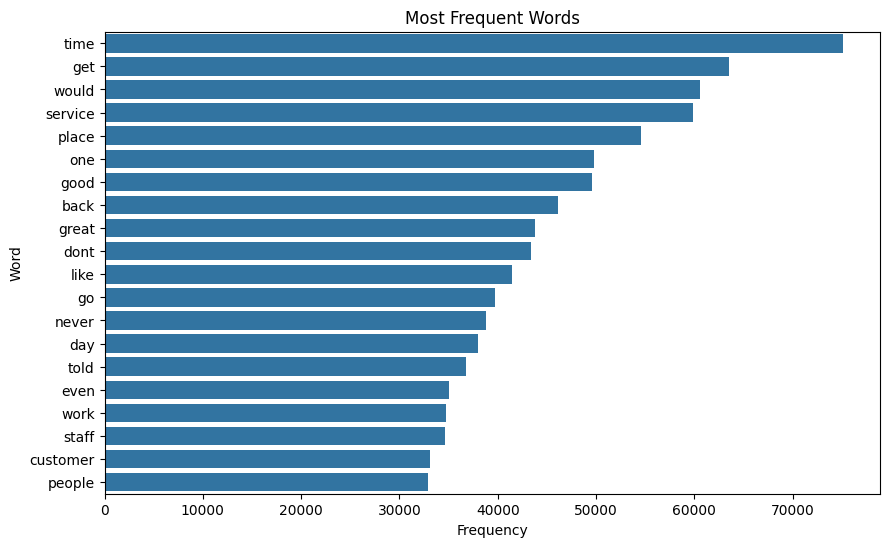

In [ ]:
# Displaying most frequent words
plt.figure(figsize=(10,6))
sns.barplot(x="Frequency", y="Word", data=common_words)
plt.title("Most Frequent Words")
plt.show()

Text normalization ensures the reviews are prepared for effective analysis by the models. Lowercasing, punctuation removal, and stopword removal reduce noise and improve feature extraction, while stemming and lemmatization reduce the vocabulary size and capture semantic meaning. These techniques are particularly effective for the Google Maps reviews dataset, where the text is informal, sometimes noisy, and contains many variants of the same word. While each technique has trade-offs (e.g., punctuation may convey sentiment, stemming creates non-dictionary words (studies → studi)), the overall benefit is improved model performance and reduced sparsity in feature representations.

## **Vector space Model and feature representation**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
X = train["text_lemma"]   # Input Features
y = train["rating"]       # Target Labels

In [ ]:
# Binary representation (words present or not)
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(X)

print(X_binary.shape)

(288000, 138760)


In [ ]:
# Bag-of-Words (Count frequency of words)
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(X)

print(X_bow.shape)

(288000, 138760)


In [ ]:
# Term Frequency - Inverse Document Frequency
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X)

print(X_tfidf.shape)

(288000, 138760)


In [ ]:
# Unigrams
tfidf_uni = TfidfVectorizer(ngram_range=(1,1))
X_uni = tfidf_uni.fit_transform(X)

print(X_uni.shape)

(288000, 138760)


In [ ]:
# Bigrams
tfidf_bi = TfidfVectorizer(ngram_range=(1,2))
X_bi = tfidf_bi.fit_transform(X)

print(X_bi.shape)

(288000, 3027444)


In [ ]:
# Trigrams
tfidf_tri = TfidfVectorizer(ngram_range=(1,3))
X_tri = tfidf_tri.fit_transform(X)

print(X_tri.shape)

(288000, 9699147)


In [ ]:
# Comparing number of features
features = pd.DataFrame({
"Representation":["Binary","Bag-of-Words","TF-IDF","Unigram","Bigram","Trigram"],
"Features":[
X_binary.shape[1],
X_bow.shape[1],
X_tfidf.shape[1],
X_uni.shape[1],
X_bi.shape[1],
X_tri.shape[1]
]
})

features

,Representation,Features
0,Binary,138760
1,Bag-of-Words,138760
2,TF-IDF,138760
3,Unigram,138760
4,Bigram,3027444
5,Trigram,9699147


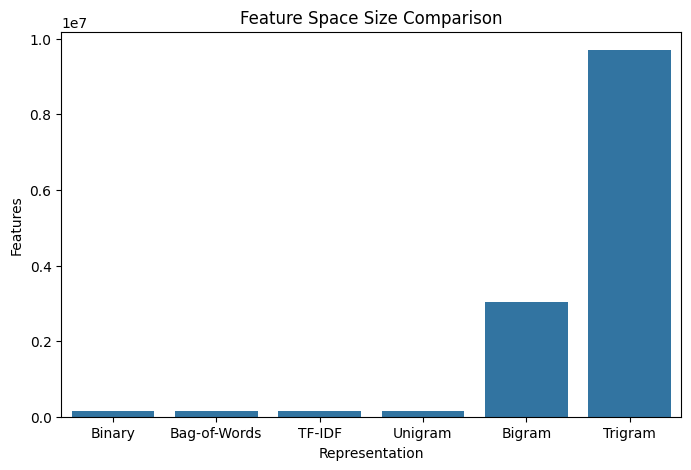

In [ ]:
# Plotting feature size comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Representation", y="Features", data=features)
plt.title("Feature Space Size Comparison")
plt.show()

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_df = pd.DataFrame({"word":feature_names,"score":tfidf_scores})
top_words = tfidf_df.sort_values("score", ascending=False).head(20)

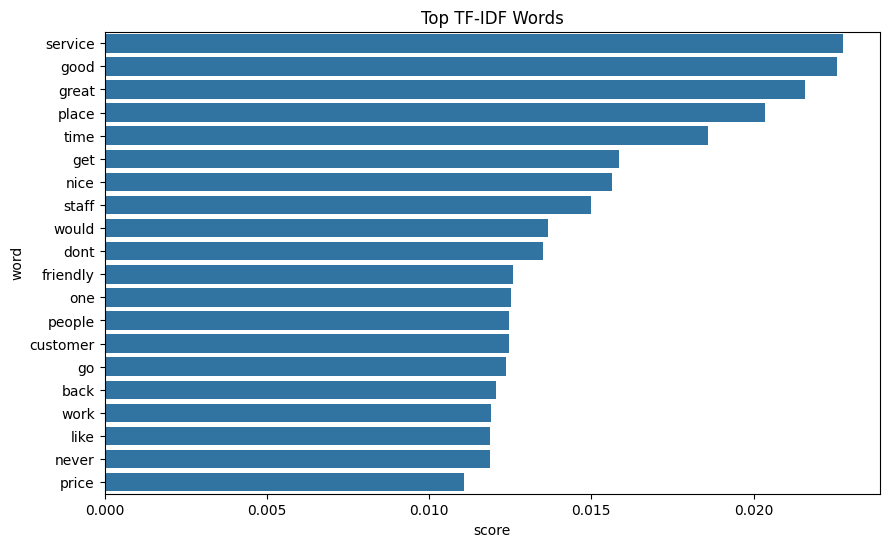

In [ ]:
# Plotting top TF-IDF words
plt.figure(figsize=(10,6))
sns.barplot(x="score", y="word", data=top_words)
plt.title("Top TF-IDF Words")
plt.show()

We experimented with multiple feature representations including Bag-of-Words, binary counts, and TF-IDF. Bag-of-Words captures raw frequency but treats all words equally, while TF-IDF highlights distinctive words that carry more information for classification. Binary features simplify the representation by considering presence only, which can be useful for short reviews. Additionally, incorporating n-gram features such as bigrams allows the model to capture contextual phrases like 'not good' or 'very clean', improving model understanding of sentiment.

### Word Embeddings

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 12.1 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Training Word2Vec model for word embedding
tokenized = train["tokens"]
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=2)

In [ ]:
print("Word vector for 'good':") # Example 1
print(model.wv["good"])
print("\n")
print("Top words most similar to 'good':")
model.wv.most_similar("good")

Word vector for 'good':
[ 1.6550432  -0.25308537  0.5796686  -1.3883839   0.86771667  2.2370474
  0.06520589 -1.4011898  -2.3848171  -0.29739106 -0.25205776  1.044753
 -0.7960051  -0.00540862 -1.0077261   0.577163   -0.95730245 -2.3521788
  0.75569683  0.28573707 -0.4931125   1.035237    0.7041446   0.88584477
  0.6834972  -1.7720686   2.6511211  -0.89422613  1.4292378  -0.5132995
  1.4170868  -1.5456952   0.23171514  1.8068173   1.3012507  -1.2687737
  1.4736817   2.1053398   1.7285122   0.4098519  -0.99864954  0.2998426
 -1.9501772   0.6033032  -0.84182245 -1.1582637   0.78147745  0.04588135
 -0.92928255  0.45157638  0.40696284  0.66453224  1.5855788  -1.5068214
  2.064287   -0.05060214  1.9440831  -2.3746552   0.10402925 -1.3555372
 -0.41621274 -0.7139043  -0.28974926  0.19142853 -1.7252084  -2.0566206
  0.12216122  0.11958472  0.93478173  0.33556157 -0.0290111  -1.9888859
 -1.5413605   1.6033573  -1.5685613  -2.3366425   0.32728228 -1.2992419
  1.845838    1.2132474   1.6428584   0

[('great', 0.830104649066925),
 ('decent', 0.7752860188484192),
 ('bad', 0.6736376285552979),
 ('ok', 0.6294416785240173),
 ('okay', 0.6137526035308838),
 ('nice', 0.6030524373054504),
 ('excellent', 0.5780634880065918),
 ('alright', 0.5778078436851501),
 ('awesome', 0.5739578604698181),
 ('perfect', 0.5533123016357422)]

In [ ]:
print("Word vector for 'bad':") # Example 2
print(model.wv["bad"])
print("\n")
print("Top words most similar to 'bad':")
model.wv.most_similar("bad")

Word vector for 'bad':
[ 3.463617   -1.3274269   0.54620796 -2.336214    1.03318    -0.05584078
  2.102983   -1.7292378  -0.61664426  0.26353762  3.0505254   2.3593538
 -1.5644631   1.4308172   0.41248697  2.8933368  -0.82312524 -2.0100248
  2.4570594  -0.17190358 -0.15787046  0.6432693   0.62579966  1.1712372
  0.7173252  -2.7185376   2.1365356  -0.4493169   1.6461504   1.2424878
 -0.3477451   0.14403458  0.41040823  1.583679    1.5295215  -0.5242148
  0.5530096   2.9063826   1.8860884   0.10289373 -0.561223    0.4616367
 -0.37096196  0.68111694 -0.5533956  -1.2689658   1.3239634  -1.2450565
 -2.1428537   0.5041153  -1.4086897   1.2002888   1.353012   -2.3692162
  0.0986222  -0.94200766  1.4583194  -1.9548912  -0.5874274   0.3139662
  0.20243609  2.0905817  -1.290297    0.05064225 -1.0819196  -2.098741
  0.82099754  0.06858818  0.41461483 -2.7203395  -0.74601907 -1.8639145
 -1.4069564   0.9494291  -0.83249575 -1.7285775   0.27082035 -3.0296562
  1.2363861   0.87204313  2.6970582  -0.1

[('terrible', 0.7427307367324829),
 ('horrible', 0.7168369293212891),
 ('good', 0.6736376881599426),
 ('poor', 0.6631001234054565),
 ('awful', 0.6409024596214294),
 ('sucks', 0.5143542885780334),
 ('unhappy', 0.5110968947410583),
 ('sad', 0.5098392367362976),
 ('weird', 0.5089236497879028),
 ('negative', 0.5089088082313538)]

In [ ]:
train.to_csv("train_processed.csv", index=False)

In [ ]:
train.head()

,text,rating,tokens,stemmed,lemmatized,text_stem,text_lemma,review_length
0,this place is terrible the people in charge ar...,2,"[place, terrible, people, charge, worst, part,...","[place, terribl, peopl, charg, worst, part, fa...","[place, terrible, people, charge, worst, part,...",place terribl peopl charg worst part far yeah ...,place terrible people charge worst part far ye...,97
1,terrible service and they are saying that i ne...,1,"[terrible, service, saying, never, used, servi...","[terribl, servic, say, never, use, servic, lie...","[terrible, service, saying, never, used, servi...",terribl servic say never use servic lie call n...,terrible service saying never used service lie...,48
2,absolutely terrible company they sent me to co...,1,"[absolutely, terrible, company, sent, collecti...","[absolut, terribl, compani, sent, collect, wit...","[absolutely, terrible, company, sent, collecti...",absolut terribl compani sent collect without a...,absolutely terrible company sent collection wi...,211
3,to find it either park in front of the tuesday...,4,"[find, either, park, front, tuesday, morning, ...","[find, either, park, front, tuesday, morn, mal...","[find, either, park, front, tuesday, morning, ...",find either park front tuesday morn mall entra...,find either park front tuesday morning mall en...,66
4,mall location used their services for sedan ni...,4,"[mall, location, used, services, sedan, nice, ...","[mall, locat, use, servic, sedan, nice, perhap...","[mall, location, used, service, sedan, nice, p...",mall locat use servic sedan nice perhap inform...,mall location used service sedan nice perhaps ...,28
